--- SEGMENT KARAKTERİSTİKLERİ ---
   customer_segment         adr  lead_time  total_of_special_requests  \
0                 0  141.801459   74.72155                   1.416279   
1                 1   83.993627   44.48549                   0.246665   
2                 2   88.725886  238.35651                   0.266530   

   is_repeated_guest  is_canceled  customer_count  
0           0.010543     0.280620            6450  
1           0.060562     0.328136           11096  
2           0.002215     0.579243            5868  


C:\Users\Sude\AppData\Local\Temp\ipykernel_10804\4022802213.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




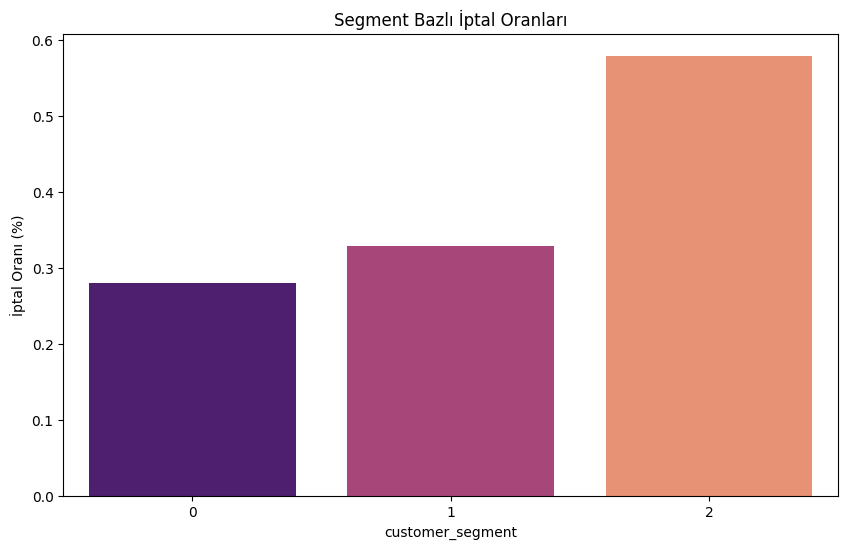

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('data_warehouse_segmented.csv')

segment_summary = df.groupby('customer_segment').agg({
    'adr': 'mean',
    'lead_time': 'mean',
    'total_of_special_requests': 'mean',
    'is_repeated_guest': 'mean',
    'is_canceled': 'mean',
    'reservation_id': 'count'
}).rename(columns={'reservation_id': 'customer_count'}).reset_index()

print("--- SEGMENT KARAKTERİSTİKLERİ ---")
print(segment_summary)

fig1 = px.pie(segment_summary, values='customer_count', names='customer_segment', 
             title='Müşteri Sayısı Dağılımı (Hangi Gruptan Kaç Kişi Var?)',
             hole=0.4, color_discrete_sequence=px.colors.sequential.RdBu)
fig1.show(renderer="browser")

plt.figure(figsize=(10, 6))
sns.barplot(x='customer_segment', y='is_canceled', data=segment_summary, palette='magma')
plt.title('Segment Bazlı İptal Oranları')
plt.ylabel('İptal Oranı (%)')
plt.show()

monthly_segment = df.groupby(['arrival_date_month', 'customer_segment'])['adr'].mean().reset_index()
ordered_months = ["January", "February", "March", "April", "May", "June", 
                  "July", "August", "September", "October", "November", "December"]
monthly_segment['arrival_date_month'] = pd.Categorical(monthly_segment['arrival_date_month'], categories=ordered_months, ordered=True)

fig2 = px.line(monthly_segment, x='arrival_date_month', y='adr', color='customer_segment',
              title='Segmentlere Göre Aylık Ortalama Fiyat (ADR) Trendi',
              markers=True)
fig2.show(renderer="browser")